Последовательности длины N = 64


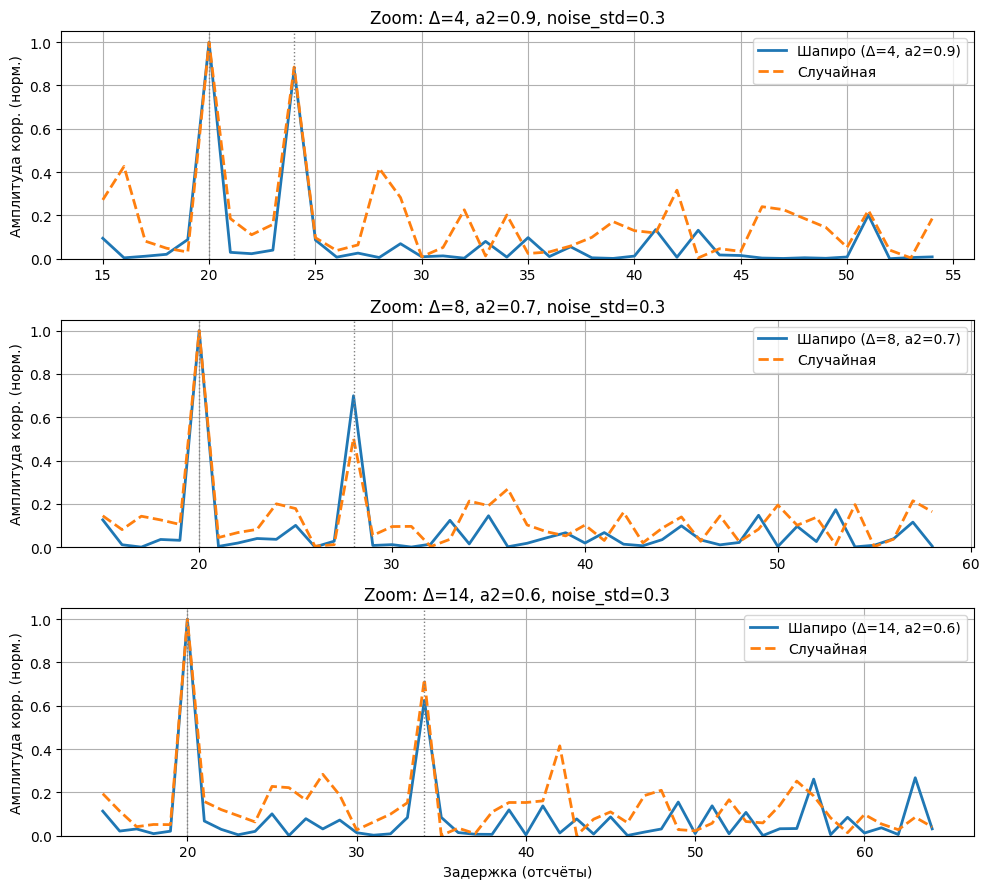

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# ----------------------
# Настройки
# ----------------------
shapiro_file = "../files/shapiro_polynomial.txt"
random_file = "../files/random_polynomial.txt"

n_pulses = 5       # число подряд посылаемых импульсов
pulse_gap = 10      # пауза между импульсами (в отсчётах)
noise_std = 0.3    # стандартное отклонение шума (по амплитуде)
# три набора для демонстрации: (delta, a2) - расстояние между целями и амплитуда второй
cases = [
    (4, 0.9),   # очень близко
    (8, 0.7),   # средне
    (14, 0.6),  # далеко
]
# zoom-окно вокруг первых двух пиков (левый и правый от ранней позиции)
zoom_left_margin = -5
zoom_right_margin = 30

# ----------------------
# Утилиты
# ----------------------
def load_sequence(filename):
    s = np.loadtxt(filename, dtype=float)
    if np.min(s) == 0 and np.max(s) == 1:
        s = 2*s - 1
    return s.astype(float)

def make_pulse_train(single_pulse, n_pulses=3, pulse_gap=60):
    n = len(single_pulse)
    total_len = n_pulses * (n + pulse_gap)
    train = np.zeros(total_len)
    for k in range(n_pulses):
        start = k * (n + pulse_gap)
        train[start:start + n] = single_pulse
    return train

def make_echo(train, delays, amps, noise_std=0.0):
    L = len(train) + max(delays)
    echo = np.zeros(L)
    for d,a in zip(delays, amps):
        echo[d:d + len(train)] += a * train
    if noise_std > 0:
        echo += np.random.normal(0, noise_std, size=len(echo))
    return echo

def corr_abs_norm(ref, recv):
    C = correlate(recv, ref, mode='full')
    C_abs = np.abs(C)
    if np.max(C_abs) == 0:
        return None, None
    C_norm = C_abs / np.max(C_abs)
    lags = np.arange(-len(ref) + 1, len(recv))
    return lags, C_norm


sh = load_sequence(shapiro_file)
rn = load_sequence(random_file)
N = len(sh)
print(f"Последовательности длины N = {N}")

# подготовка pulse trains
train_sh = make_pulse_train(sh, n_pulses=n_pulses, pulse_gap=pulse_gap)
train_rn = make_pulse_train(rn, n_pulses=n_pulses, pulse_gap=pulse_gap)

# ----------------------
# Построение 3 субплотов (zoom)
# ----------------------
fig, axes = plt.subplots(len(cases), 1, figsize=(10, 3*len(cases)), sharex=False)

for ax, (delta, a2) in zip(axes, cases):
    # delays — для всей тренировки (пики будут повторяться для каждого посыла)
    # модель эха: несколько целей (для простоты возьмём только две)
    delays = [20, 20 + delta]  # смещаем обе цели от начала train; 20 — безопасный отступ
    amps = [1.0, a2]

    # формируем эхо для каждого train
    echo_sh = make_echo(train_sh, delays, amps, noise_std=noise_std)
    echo_rn = make_echo(train_rn, delays, amps, noise_std=noise_std)

    # корреляции (абсолютные)
    lags_sh, corr_sh = corr_abs_norm(train_sh, echo_sh)
    lags_rn, corr_rn = corr_abs_norm(train_rn, echo_rn)

    # определяем zoom-границы вокруг первой пары пиков (они появятся в lags ~ delays)
    # Ориентируемся на первую появляющуюся пару пиков (для первой посылки)
    first_peak_pos = delays[0]  # в lags позиция примерно равна задержке
    left = first_peak_pos + zoom_left_margin
    right = first_peak_pos + delta + zoom_right_margin

    # маски для отрисовки
    mask_sh = (lags_sh >= left) & (lags_sh <= right)
    mask_rn = (lags_rn >= left) & (lags_rn <= right)

    # рисуем (только положительные значения по y — корр. абсолютная)
    ax.plot(lags_sh[mask_sh], corr_sh[mask_sh], label=f"Шапиро (Δ={delta}, a2={a2})", linewidth=2)
    ax.plot(lags_rn[mask_rn], corr_rn[mask_rn], '--', label="Случайная", linewidth=2)
    ax.set_ylabel("Амплитуда корр. (норм.)")
    ax.set_title(f"Zoom: Δ={delta}, a2={a2}, noise_std={noise_std}")
    # пометим ожидаемые позиции пиков первой посылки
    ax.axvline(first_peak_pos, color='gray', linestyle=':', linewidth=1)
    ax.axvline(first_peak_pos + delta, color='gray', linestyle=':', linewidth=1)
    ax.set_ylim(0, 1.05)  # от 0 до чуть выше 1 (мы убрали отрицательные)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Задержка (отсчёты)")
plt.tight_layout()
plt.show()


Последовательности длины N = 64


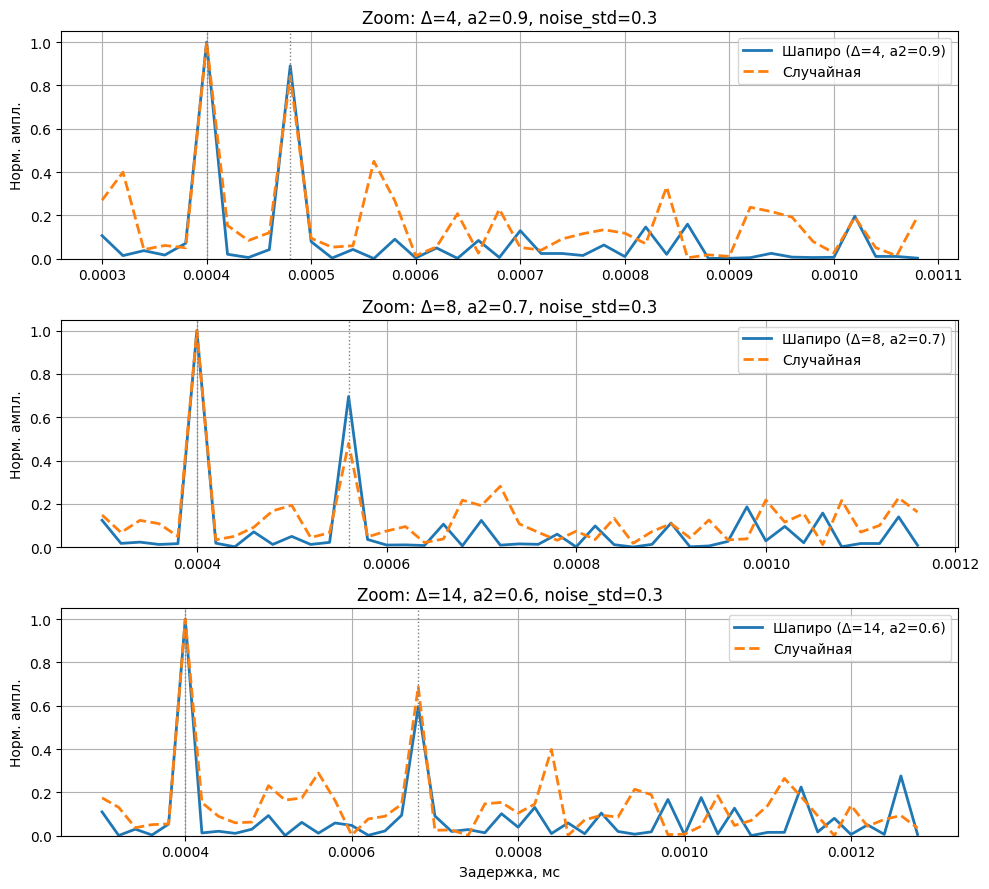

 Δ  Цель #  Ожидаемая задержка, мс  Шапиро (ампл.) Шапиро (обнаружено)  Случайная (ампл.) Случайная (обнаружено)
 4       1                0.000400        1.000000                  Да           1.000000                     Да
 4       2                0.000480        0.891009                  Да           0.843276                     Да
 8       1                0.000400        1.000000                  Да           1.000000                     Да
 8       2                0.000560        0.696142                  Да           0.479734                    Нет
14       1                0.000400        1.000000                  Да           1.000000                     Да
14       2                0.000680        0.596033                  Да           0.688269                     Да


In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
import pandas as pd

# ---------------------- ПАРАМЕТРЫ ----------------------
shapiro_file = "../files/shapiro_polynomial.txt"
random_file = "../files/random_polynomial.txt"

fs = 50e6              # частота дискретизации, Гц (для перевода отсчётов в мс)
n_pulses = 5           # число подряд посылаемых импульсов
pulse_gap = 10         # пауза между импульсами (в отсчётах)
noise_std = 0.3        # стандартное отклонение шума
# три набора для демонстрации: (delta, a2) - расстояние между целями и амплитуда второй
cases = [
    (4, 0.9),   # очень близко
    (8, 0.7),   # средне
    (14, 0.6),  # далеко
]
zoom_left_margin = -5
zoom_right_margin = 30

# ---------------------- ФУНКЦИИ ----------------------
def load_sequence(filename):
    s = np.loadtxt(filename, dtype=float)
    if np.min(s) == 0 and np.max(s) == 1:
        s = 2*s - 1
    return s.astype(float)

def make_pulse_train(single_pulse, n_pulses=3, pulse_gap=60):
    n = len(single_pulse)
    total_len = n_pulses * (n + pulse_gap)
    train = np.zeros(total_len)
    for k in range(n_pulses):
        start = k * (n + pulse_gap)
        train[start:start + n] = single_pulse
    return train

def make_echo(train, delays, amps, noise_std=0.0):
    L = len(train) + max(delays)
    echo = np.zeros(L)
    for d,a in zip(delays, amps):
        echo[d:d + len(train)] += a * train
    if noise_std > 0:
        echo += np.random.normal(0, noise_std, size=len(echo))
    return echo

def corr_abs_norm(ref, recv):
    C = correlate(recv, ref, mode='full')
    C_abs = np.abs(C)
    if np.max(C_abs) == 0:
        return None, None
    C_norm = C_abs / np.max(C_abs)
    lags = np.arange(-len(ref) + 1, len(recv))
    return lags, C_norm

# ---------------------- Загрузка последовательностей ----------------------
sh = load_sequence(shapiro_file)
rn = load_sequence(random_file)
N = len(sh)
print(f"Последовательности длины N = {N}")

train_sh = make_pulse_train(sh, n_pulses=n_pulses, pulse_gap=pulse_gap)
train_rn = make_pulse_train(rn, n_pulses=n_pulses, pulse_gap=pulse_gap)

# ---------------------- Построение графиков и таблицы ----------------------
results = []

fig, axes = plt.subplots(len(cases), 1, figsize=(10, 3*len(cases)), sharex=False)

for ax, (delta, a2) in zip(axes, cases):
    delays = [20, 20 + delta]
    amps = [1.0, a2]

    echo_sh = make_echo(train_sh, delays, amps, noise_std=noise_std)
    echo_rn = make_echo(train_rn, delays, amps, noise_std=noise_std)

    lags_sh, corr_sh = corr_abs_norm(train_sh, echo_sh)
    lags_rn, corr_rn = corr_abs_norm(train_rn, echo_rn)

    # Перевод в миллисекунды
    lags_sh_ms = lags_sh / fs * 1000
    lags_rn_ms = lags_rn / fs * 1000

    # Маска для zoom
    first_peak_pos = delays[0]
    left = first_peak_pos + zoom_left_margin
    right = first_peak_pos + delta + zoom_right_margin
    mask_sh = (lags_sh >= left) & (lags_sh <= right)
    mask_rn = (lags_rn >= left) & (lags_rn <= right)

    ax.plot(lags_sh_ms[mask_sh], corr_sh[mask_sh], label=f"Шапиро (Δ={delta}, a2={a2})", linewidth=2)
    ax.plot(lags_rn_ms[mask_rn], corr_rn[mask_rn], '--', label="Случайная", linewidth=2)
    ax.set_ylabel("Норм. ампл.")
    ax.set_title(f"Zoom: Δ={delta}, a2={a2}, noise_std={noise_std}")
    ax.axvline(delays[0]/fs*1000, color='gray', linestyle=':', linewidth=1)
    ax.axvline((delays[0]+delta)/fs*1000, color='gray', linestyle=':', linewidth=1)
    ax.set_ylim(0, 1.05)
    ax.grid(True)
    ax.legend()

    # ---------------------- Таблица результатов ----------------------
    for i, d in enumerate(delays):
        # Находим индекс в массиве lags, который соответствует задержке d
        idx_sh = np.argmin(np.abs(lags_sh - d))
        idx_rn = np.argmin(np.abs(lags_rn - d))

        amp_sh = corr_sh[idx_sh]
        amp_rn = corr_rn[idx_rn]
        detected_sh = 'Да' if amp_sh > 0.4 else 'Нет'
        detected_rn = 'Да' if amp_rn > 0.5 else 'Нет'
        results.append({
            'Δ': delta,
            'Цель #': i+1,
            'Ожидаемая задержка, мс': d/fs*1000,
            'Шапиро (ампл.)': amp_sh,
            'Шапиро (обнаружено)': detected_sh,
            'Случайная (ампл.)': amp_rn,
            'Случайная (обнаружено)': detected_rn
        })


axes[-1].set_xlabel("Задержка, мс")
plt.tight_layout()
plt.show()

# ---------------------- Вывод таблицы ----------------------
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False, float_format='%.6f'))
